In [1]:
import os
import os, sys
import scipy
import pandas as pd
import scanpy as sc
# import dask
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(12, 12))


In [2]:
DATA_PREPARED = True



In [3]:
if not DATA_PREPARED:
    RUNID=4
    BASE_DIR = f'/nfs/team361/aa36/OnGit/inflow-reproducibility/Analysis/18_Melanoma_Jan20Runs/NonGit/RunOutputs/Jan26_20_00/Output_Path_Run{RUNID}/'
    os.listdir(BASE_DIR)

    adata=sc.read_h5ad(BASE_DIR +  'adata_inflowOutput_norm.h5ad' )
    adata

    def remove_markers(LIST):
        try: 
            LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                               for key, genes in LIST.items()}
        except: 
            LIST =[gene for gene in LIST if gene in adata_5k.var_names]
        return LIST


    try:
        adata.obs["NICHE_NAMES"] = adata.obs["niche_name"]
    except:
        adata


    x_int = adata.obsm["inflow_muxint"]
    x_spl = adata.obsm["inflow_muxspl"]   
    key_celltype = "broad_celltypes" 
    adata
    M_BAR_METRIC='inflow_muxbar_int'
    adata.layers["xint"]=x_int#adata.obsm["pred_Xint"].copy()
    adata.layers["xspl"]=x_spl#adata.obsm["pred_Xspl"].copy()
else:
    adata=sc.read_h5ad('/nfs/team361/ls34/inflow/final_adatas/adata_intrinsic_mm_final.h5ad')

# INT first

In [4]:
if not DATA_PREPARED:
    try:
        del(adata.obsm["X_pca"])
    except:
        print("no x_pca present ")
        
    if "spl" in M_BAR_METRIC:
        LAYER = "xspl"
    else:
        LAYER = "xint"
    print(LAYER)

In [5]:
if not DATA_PREPARED:
    sc.pp.pca(adata, n_comps=30, layer=LAYER)

In [6]:
if not DATA_PREPARED:
    sc.pp.neighbors(adata, use_rep = 'X_pca', 
                metric = "euclidean", n_neighbors=60)#key_added=neighbor_id)



In [7]:
if not DATA_PREPARED:
    sc.tl.umap(adata, min_dist=0.3) #neighbor_key=)


In [8]:
if not DATA_PREPARED:
    RES=0.5
    sc.tl.leiden(adata, #restrict_to=(CATEGORY,subset_cluster), 
                 resolution=RES, random_state=1, key_added=f'leiden_res{RES}') #neighbors_key='neighbor_30')


    sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(12, 12))
    sc.pl.umap(adata,  
               color=[f'leiden_res{RES}', key_celltype],
               s=20,
              # legend_loc="on data",
               legend_fontsize=8)



In [9]:
# RENAME = {'11': 'Keratinocyte',
#  '0':  'Immune',
#  '8':  'Epidermis basal',
#  '4': 'Melanoma',
#  '2': 'Fibroblast',
#  '1': 'Melanoma',
#  '6': 'Immune',
#  '10': 'Plasma cell',
#  '7': 'Melanoma',
#  '5': 'Melanoma',
#  '9': 'VE/Pericyte',
#  '3': 'Melanoma',
#  '12': 'Immune'}
# adata.obs["intrinsic"] =adata.obs[f'leiden_res{RES}'].map(RENAME)

In [10]:
# # Specify the number of top contributors to display
# top_n = 4
# GROUP =  f"leiden_res{RES}"

# # Group by `niche_name` and `Annotation`, and count occurrences
# grouped_data = (
#     adata.obs.groupby([GROUP, key_celltype])
#     .size()
#     .reset_index(name="count")
# )

# # Calculate the total count for each `niche_name`
# grouped_data["total_count"] = grouped_data.groupby(GROUP)["count"].transform("sum")

# # Calculate the percentage contribution for each `Annotation` within its `niche_name`
# grouped_data["percentage"] = round((grouped_data["count"] / grouped_data["total_count"]) * 100)

# # Sort the counts in descending order within each `niche_name` group
# sorted_data = grouped_data.sort_values(
#     [GROUP, "count"], ascending=[True, False]
# )

# # Extract the top N contributors for each group
# top_contributors = sorted_data.groupby(GROUP).head(top_n)

# import pandas as pd

# # Remove the display limit
# pd.set_option('display.max_rows', None)

# # Display the result
# top_contributors

In [11]:
if not DATA_PREPARED:
    RENAME = {'KCinflamm_late': 'KCinflamm_late',
     'KCinflamm_final': 'KCinflamm_final',
     'KCinflamm_int': 'KCinflamm_int',
     'KCinflamm_basal': 'KCinflamm_basal',
     'cDC2': 'cDC2',
     'LC': 'LC',
     'T': 'T',
     'Mast cell': 'Mast cell',
     'Melanoma': 'Melanoma',
     'F6: Myofibroblast inflammatory': 'Cancer-associated fibroblast',
     'F1: Superficial': 'Fibroblast',
     'Mac': 'Mac',
     'Nonspecific': 'Nonspecific',
     'Plasma cell': 'Plasma cell',
     'Pericyte': 'Pericyte',
     'cDC1': 'cDC1',
     'LE': 'LE',
     'F6: Myofibroblast': 'Cancer-associated fibroblast',
     'VE': 'VE',
     'MigDC': 'MigDC'}
    adata.obs["key_celltype_new"]=adata.obs[key_celltype].map(RENAME)

    COLORS = {'KCinflamm_late': '#f4e9ef',
     'KCinflamm_final': '#E07090',
     'KCinflamm_int': '#007FFF',
     'KCinflamm_basal': '#f4e9ef',
     'cDC2': '#6F478C',
     'LC': '#3bc1d9',
     'T': '#F4D1A1',
     'Mast cell': '#FF5F00',
     'Melanoma': '#3D1C02',
     'F6: Myofibroblast inflammatory': 'Cancer-associated fibroblast',
     'Fibroblast': '#FFFFE4',
     'Mac': '#1B03A3',
     'Nonspecific': '#D3D3D3',
     'Plasma cell': '#ff5e00',
     'Pericyte': '#F7A3C3',
     'cDC1': '#9B70C1',
     'LE': '#FFFF00',
     'Cancer-associated fibroblast':"#52aaff" ,
     'VE': '#d73435',
     'MigDC': '#00FF00'}




    adata.obs["key_celltype_new"]=adata.obs["key_celltype_new"].astype('category')
    color_palette = [COLORS[cell_type] for cell_type in adata.obs["key_celltype_new"].cat.categories]

    sc.pl.umap(
        adata,  
        color=["key_celltype_new"], 
        s=10, 
        legend_fontsize=8,
        title="",
        palette=color_palette  ,
    )

# supp fig 6a

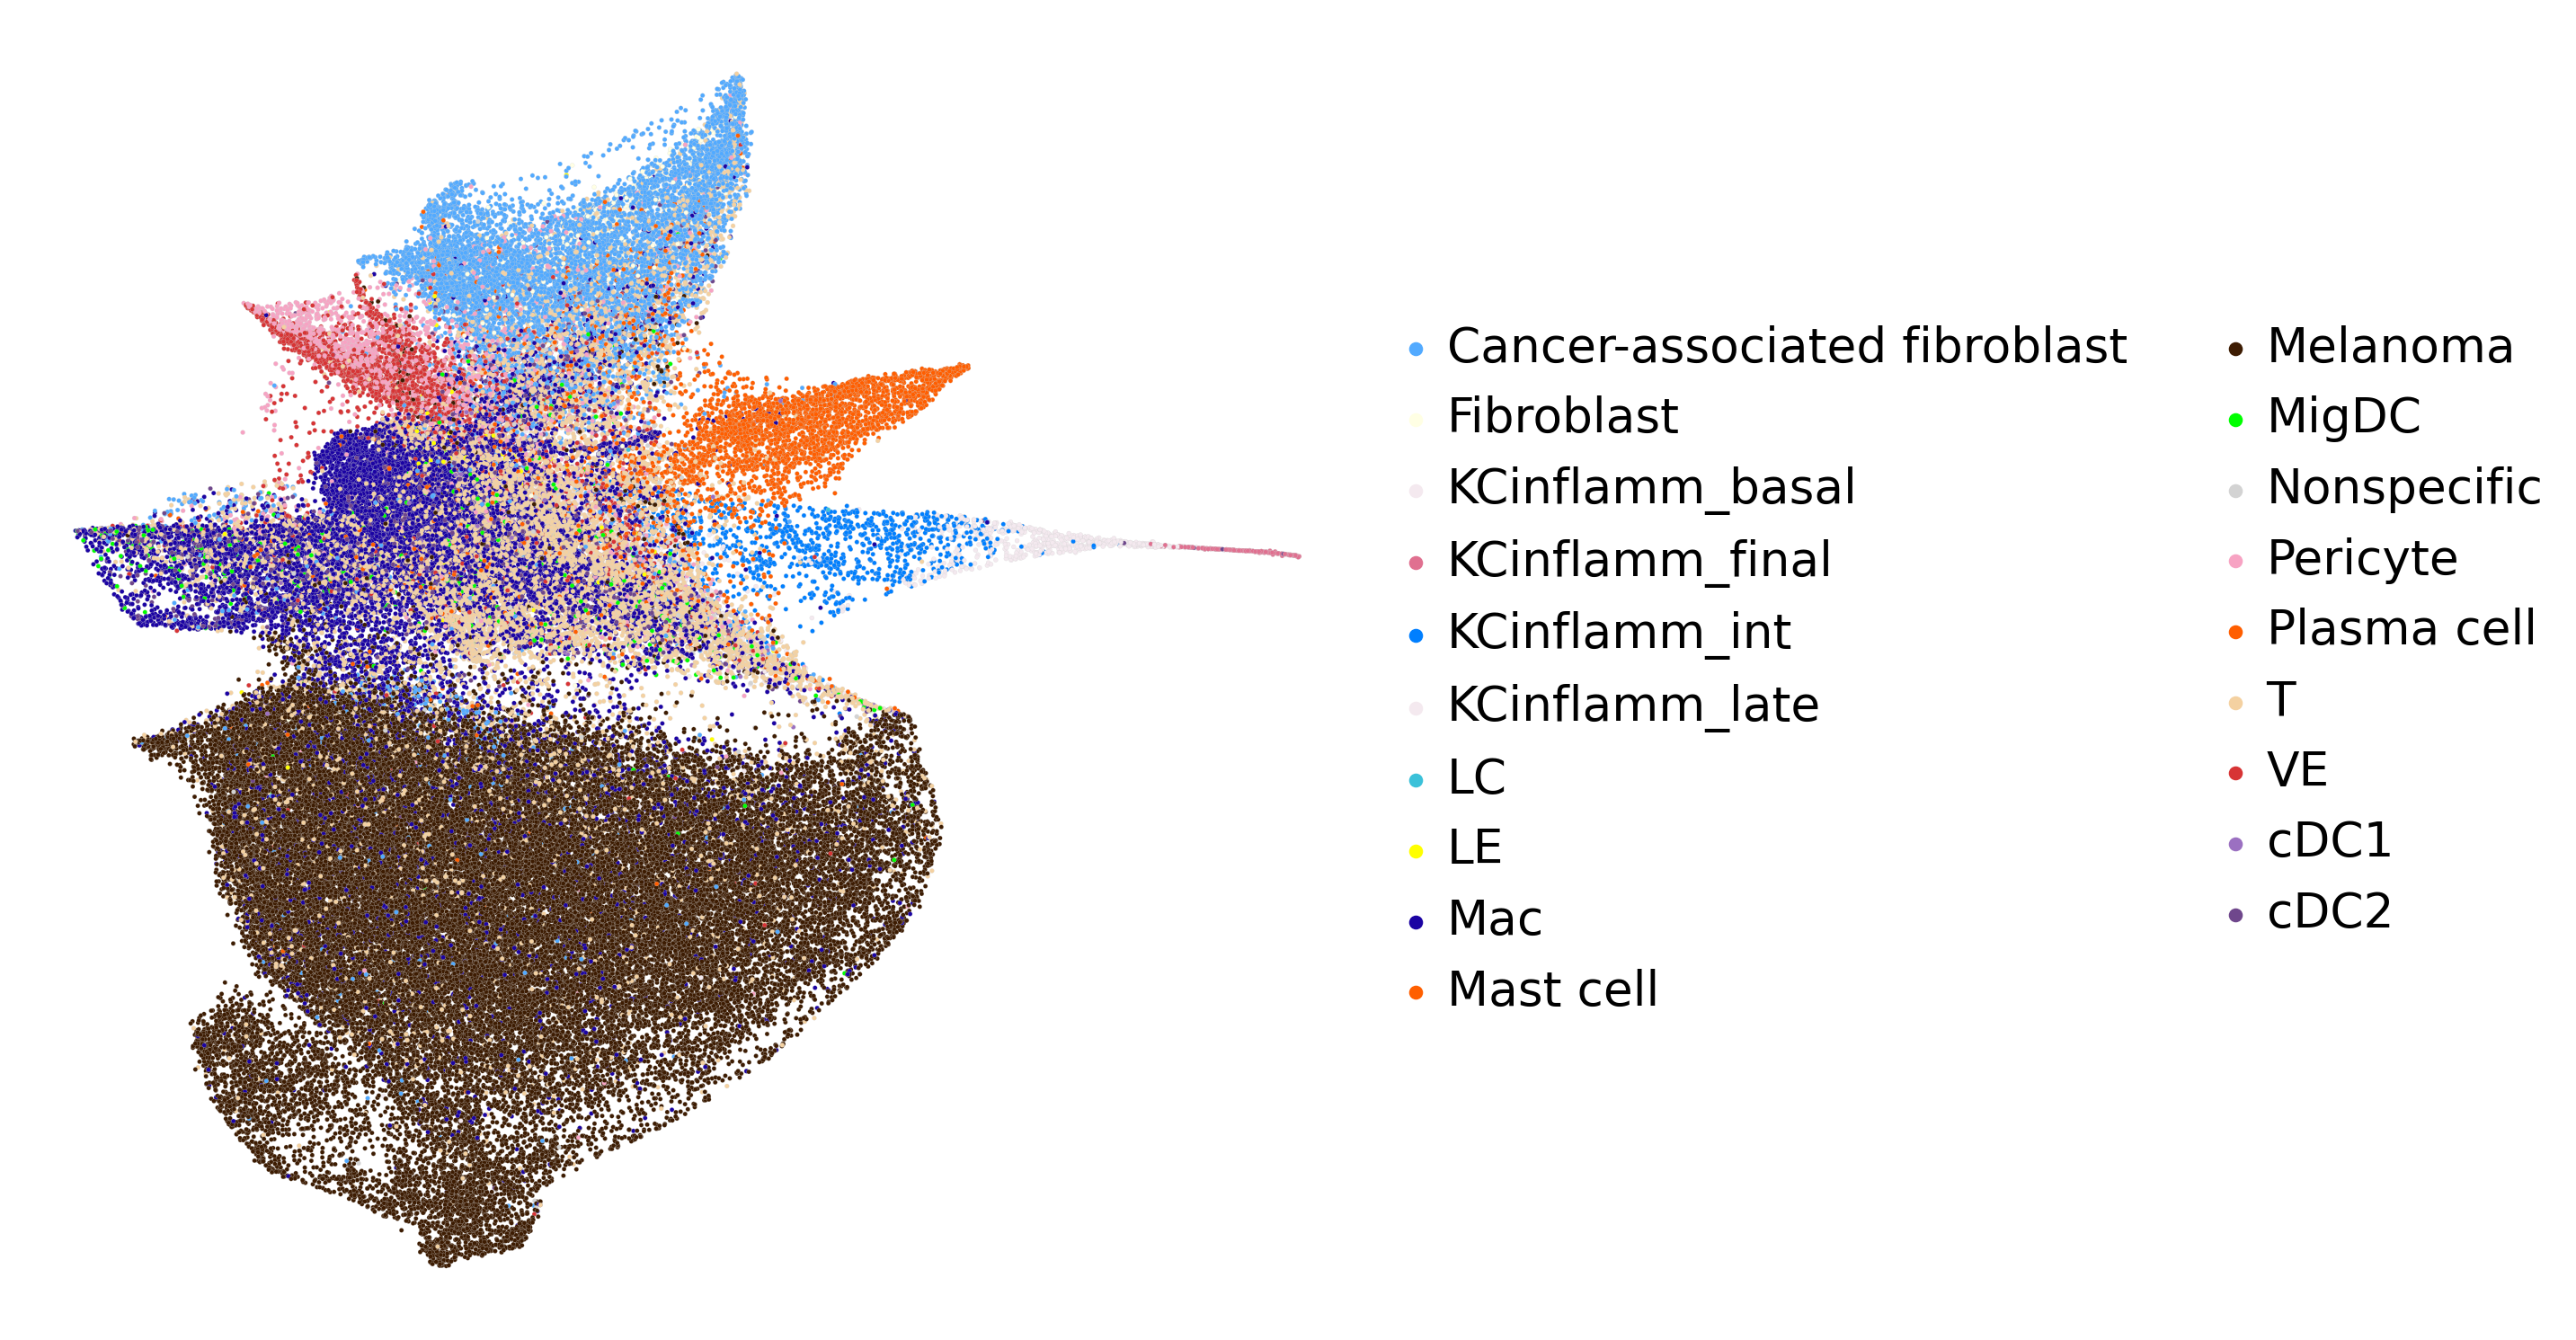

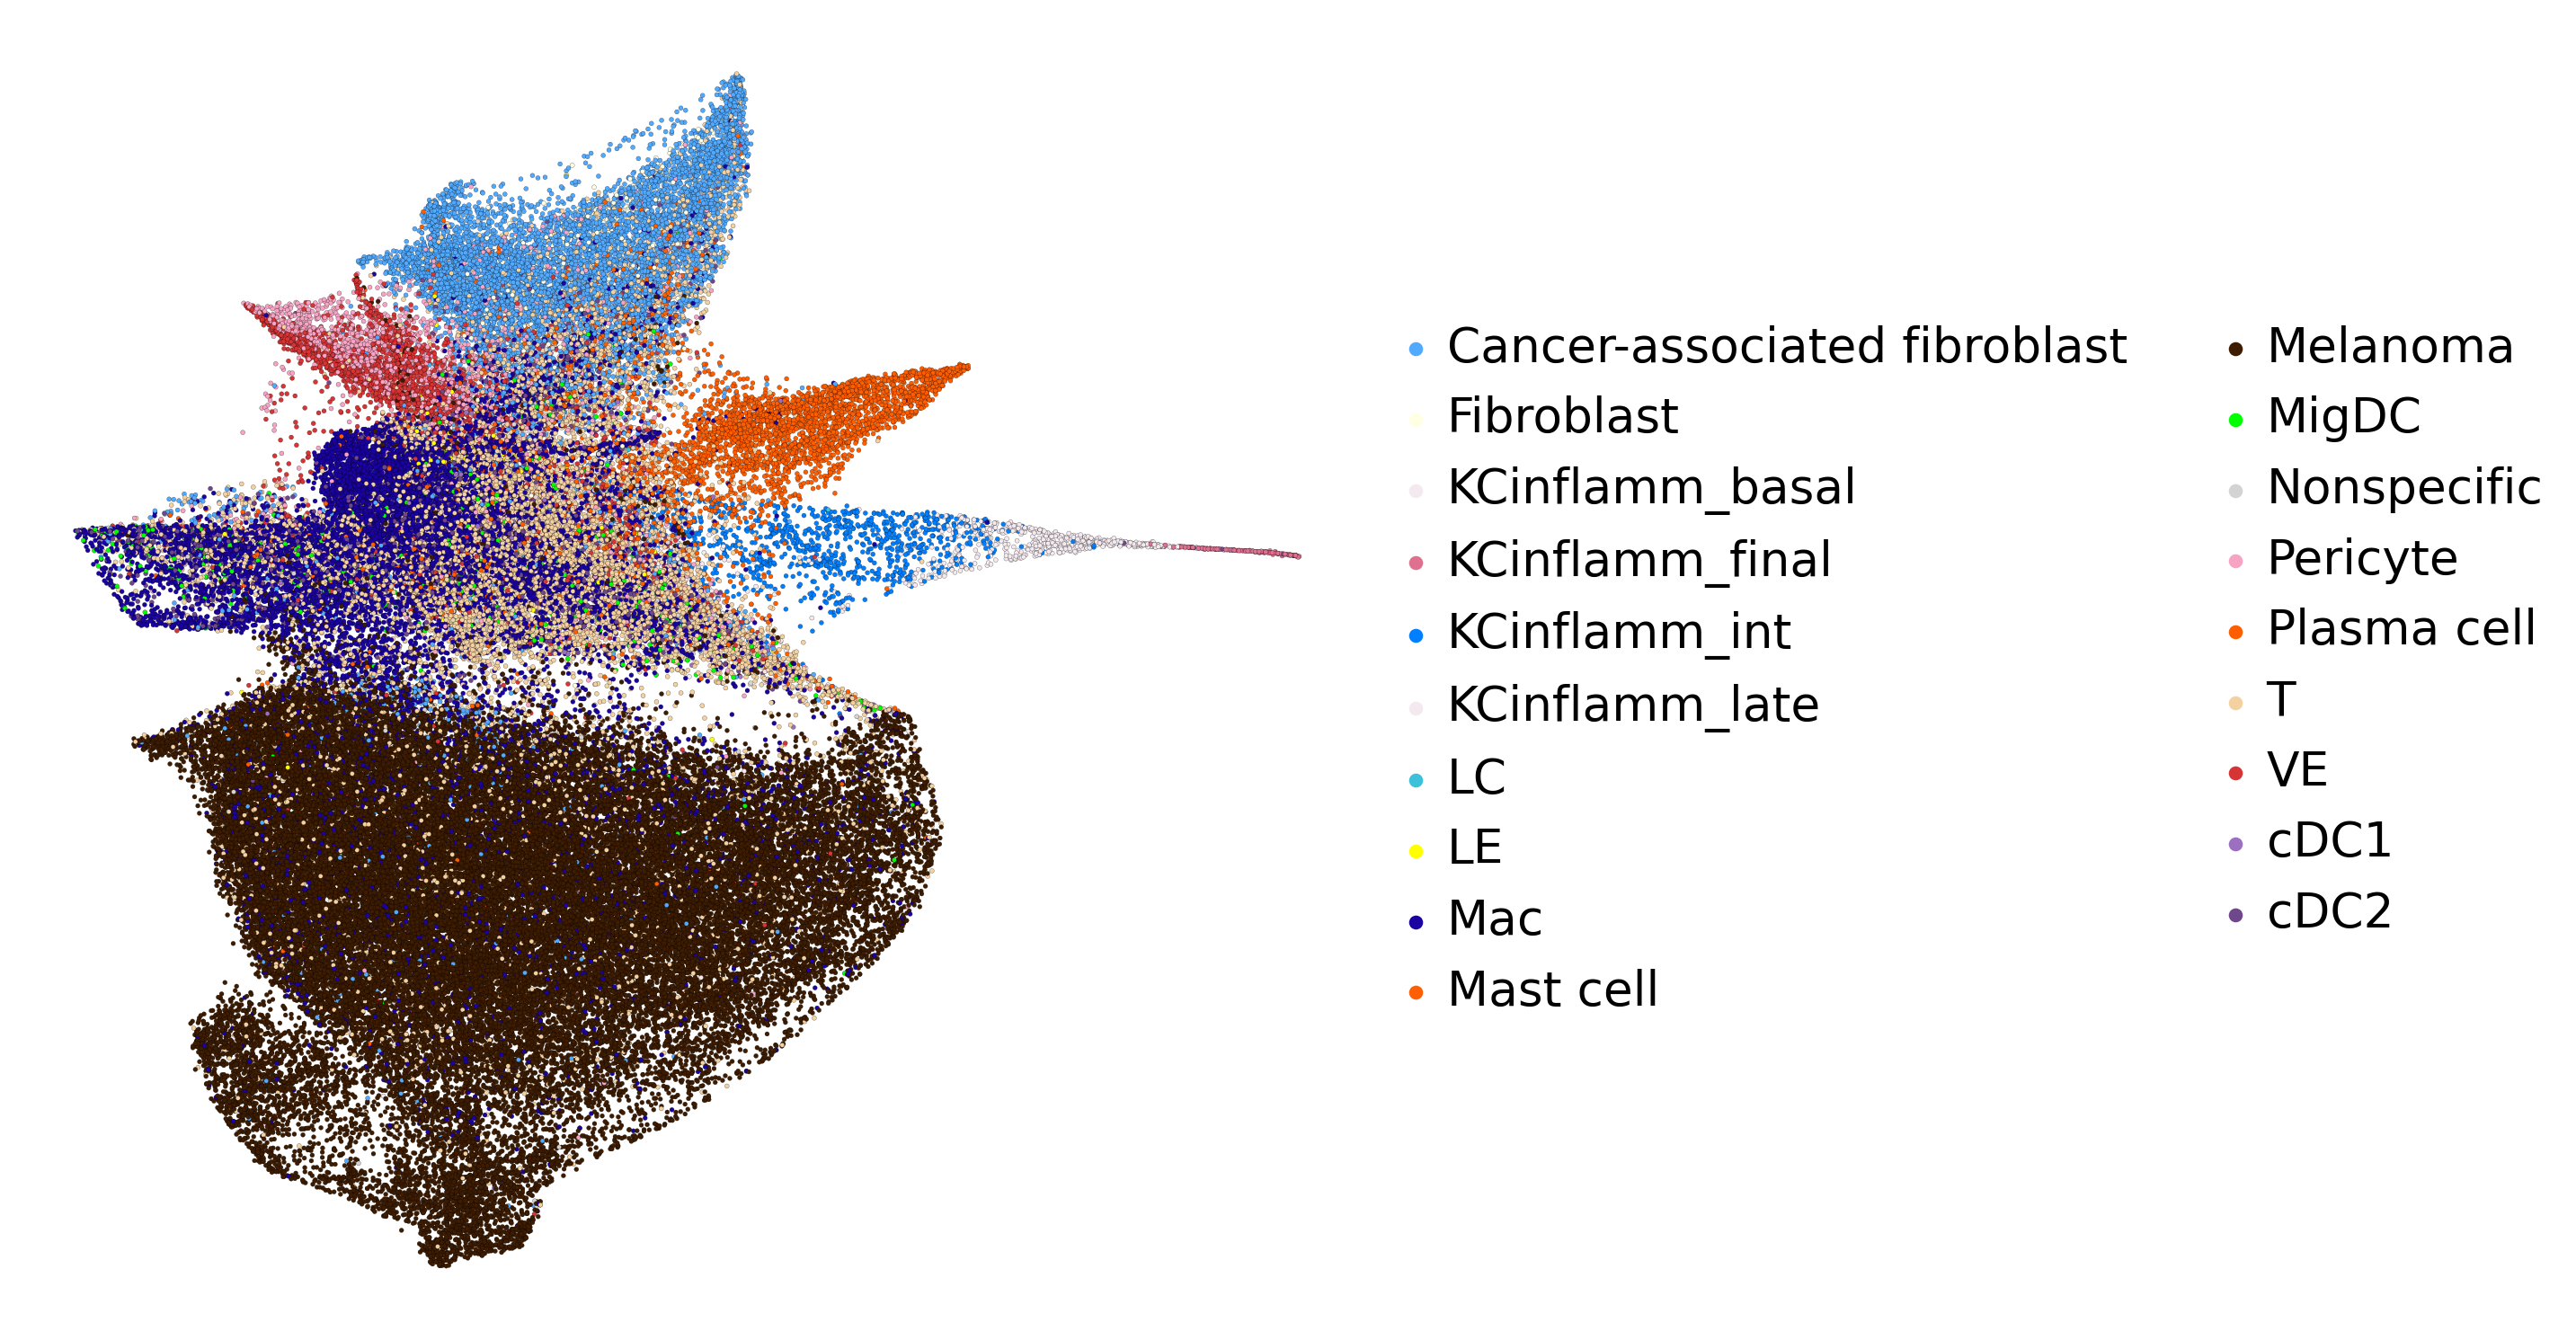

In [14]:
sc.pl.umap(
    adata,
    color=['key_celltype_new'],
    s=20,
#legend_loc=None,
    legend_fontsize=24,
    legend_fontoutline=2,
    title="",
    linewidth=0.1,
            edgecolor="lightgrey",
        save = "intrinsic_umap.pdf"

   # alpha=0.6

)

sc.pl.umap(
    adata,
    color=['key_celltype_new'],
    s=20,
#legend_loc=None,
    legend_fontsize=24,
    legend_fontoutline=2,
    title="",
    linewidth=0.1,
            edgecolor="black",
        save="intrinsic_umap_mm_withoutline.pdf"

   # alpha=0.6

)
 